# Prompting, Calibration and RL (20 points)

Large Language Models often produce answers together with an implicit notion of confidence (e.g., based on token probabilities).  
An important question is whether this confidence can be trusted.

A useful property of predictive models is **calibration**. A model is calibrated when its confidence matches the probability that its predictions are correct. For example, if a model assigns 70% confidence to a large group of predictions, then roughly 70% of those predictions should be correct.

Calibration is important when LLMs are used in real applications, because users may rely on confidence estimates to decide when the model’s output should be trusted.

There are several approaches that can improve the calibration of neural models, including:

- temperature scaling (https://arxiv.org/pdf/1706.04599.pdf)
- fine-tuning the model (https://arxiv.org/pdf/2402.06544.pdf)
- post-hoc estimation of response probabilities (https://arxiv.org/abs/2207.05221)
- prompting strategies such as explanation-based prompting with self-consistency (https://arxiv.org/pdf/2402.13904.pdf)

Another widely used approach for improving LLM behavior is reinforcement learning (RL). In RL-based training, models are optimized using feedback about which outputs are preferred. In this assignment we will use a simplified form of RL-based alignment called Direct Preference Optimization (DPO), where the model learns from pairs of preferred and rejected responses.

In this assignment you will explore how prompting strategies and preference-based fine-tuning influence both model accuracy and calibration.

Cells that require your responses are marked with **TODO**.

---

Before starting the experiments, we install the required dependencies.

For model inference we use the [vLLM](https://github.com/vllm-project/vllm) library, which provides a highly optimized implementation for running LLMs. In practice, vLLM is often significantly faster than standard inference with libraries such as [Transformers](https://github.com/huggingface/transformers).

vLLM can sometimes be sensitive to the runtime environment and library versions. For this assignment we therefore recommend using **Google Colab with a T4 GPU runtime**. However, the notebook can also be adapted to run on other machines with a GPU.

To select the correct runtime in Colab:

**Runtime → Change runtime type → Hardware accelerator → T4 GPU**

If you encounter issues when initializing the vLLM model, try restarting the runtime:

**Runtime → Disconnect and delete runtime → reconnect the T4 runtime (upper-right)**

In [1]:
# Install required dependencies

# Note: You may see dependency warnings related to `google-ai-generativelanguage`,
# `tensorflow`, or `grpcio`. These can be safely ignored, as they are not
# required for this assignment.

!pip -q install vllm==0.16.0
!pip -q install protobuf==5.29.6
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 1

We will use the following components from the vLLM library:

- [LLM](https://docs.vllm.ai/en/v0.7.2/api/offline_inference/llm.html) – class used to initialize and load a language model by name.
- [SamplingParams](https://docs.vllm.ai/en/v0.6.4/dev/sampling_params.html) – class that defines generation parameters such as the number of samples, temperature etc.
- [llm.generate](https://docs.vllm.ai/en/stable/models/generative_models/#llmgenerate) – method used to generate model outputs for a given prompt.

More details can be found in the vLLM documentation:  
https://docs.vllm.ai/en/latest/getting_started/quickstart.html

In [2]:
import torch
import numpy as np
from vllm import LLM, SamplingParams

In [3]:
# Initialize LLM, can take up to 5-6 mins
llm = LLM(model="Qwen/Qwen2.5-Math-1.5B")

INFO 05-18 06:32:28 [utils.py:223] non-default args: {'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-Math-1.5B'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

INFO 05-18 06:33:13 [model.py:529] Resolved architecture: Qwen2ForCausalLM
WARNING 05-18 06:33:13 [model.py:1821] Your device 'Tesla T4' (with compute capability 7.5) doesn't support torch.bfloat16. Falling back to torch.float16 for compatibility.
WARNING 05-18 06:33:13 [model.py:1874] Casting torch.bfloat16 to torch.float16.
INFO 05-18 06:33:13 [model.py:1549] Using max model len 4096
INFO 05-18 06:33:13 [scheduler.py:224] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-18 06:33:13 [vllm.py:689] Asynchronous scheduling is enabled.


generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

WARNING 05-18 06:33:15 [system_utils.py:140] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 05-18 06:38:50 [llm.py:355] Supported tasks: ['generate']


In [4]:
# Initialize default sampling parameters
sampling_params = SamplingParams(
    temperature=0,  # greedy generation
    n=1,
    max_tokens=500,
    logprobs=1,
    seed=42,
)

In [5]:
# Example prompt to test the model
prompts = ["How many letters are in word 'seventeen'?"]
outputs = llm.generate(prompts, sampling_params)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [6]:
# outputs: list[RequestOutput]
print(outputs)

[RequestOutput(request_id=0, prompt="How many letters are in word 'seventeen'?", prompt_token_ids=[4340, 1657, 11931, 525, 304, 3409, 364, 325, 684, 14911, 69990], encoder_prompt=None, encoder_prompt_token_ids=None, prompt_logprobs=None, outputs=[CompletionOutput(index=0, text=' To determine the number of letters in the word "seventeen," we will count each letter individually. Let\'s break it down step by step:\n\n1. Start with the first letter: "S" (1 letter)\n2. Next letter: "E" (2 letters)\n3. Next letter: "V" (3 letters)\n4. Next letter: "E" (4 letters)\n5. Next letter: "N" (5 letters)\n6. Next letter: "T" (6 letters)\n7. Next letter: "E" (7 letters)\n8. Next letter: "E" (8 letters)\n9. Next letter: "V" (9 letters)\n10. Next letter: "E" (10 letters)\n11. Next letter: "E" (11 letters)\n12. Next letter: "N" (12 letters)\n13. Next letter: "E" (13 letters)\n14. Next letter: "E" (14 letters)\n15. Next letter: "N" (15 letters)\n16. Next letter: "E" (16 letters)\n17. Next letter: "E" (17 

In [7]:
# generated text - example of LLM hallucination
print(outputs[0].outputs[0].text)

 To determine the number of letters in the word "seventeen," we will count each letter individually. Let's break it down step by step:

1. Start with the first letter: "S" (1 letter)
2. Next letter: "E" (2 letters)
3. Next letter: "V" (3 letters)
4. Next letter: "E" (4 letters)
5. Next letter: "N" (5 letters)
6. Next letter: "T" (6 letters)
7. Next letter: "E" (7 letters)
8. Next letter: "E" (8 letters)
9. Next letter: "V" (9 letters)
10. Next letter: "E" (10 letters)
11. Next letter: "E" (11 letters)
12. Next letter: "N" (12 letters)
13. Next letter: "E" (13 letters)
14. Next letter: "E" (14 letters)
15. Next letter: "N" (15 letters)
16. Next letter: "E" (16 letters)
17. Next letter: "E" (17 letters)

By counting each letter, we find that the word "seventeen" has 17 letters.

Thus, the number of letters in the word "seventeen" is \(\boxed{17}\).


# Question 1: Confidence Estimation (1 point)

When generating text token by token, an LLM assigns a probability to every possible next token. Tokens with higher probability indicate higher confidence, and tokens with lower probability indicate lower confidence.

To estimate the model’s confidence in the entire generated answer, rather than at the token level, we can aggregate the probabilities of the generated tokens ([source](https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00407/107277/How-Can-We-Know-When-Language-Models-Know-On-the)).

In this assignment you will compute the **average log probability** of the generated tokens and then exponentiate it to obtain a confidence score for the whole response.

Let a completion consist of tokens $x_1, \dots, x_n$ with probabilities $p(x_i)$. Compute:

$$
\exp\left(\frac{1}{n}\sum_{i=1}^{n} \log p(x_i)\right)
$$

This value can be interpreted as the model’s confidence in the generated answer.

Hint: inspect the fields of vLLM’s [`CompletionOutput`](https://github.com/vllm-project/vllm/blob/v0.16.0/vllm/outputs.py#L23), especially the `logprobs` field.

In [8]:
from vllm.outputs import RequestOutput
import numpy as np

def calculate_exp_avg_logprob(request_outputs: list[RequestOutput]) -> list[float]:
    """
    Compute an exponentiated average log-probability score for each generated completion.

    Args:
        request_outputs: List of vLLM RequestOutput objects returned by `llm.generate`.

    Returns:
        A list of scores, one per generated completion (in the same order as outputs).
    """
    scores: list[float] = []

    for request_output in request_outputs:
        for completion_output in request_output.outputs:
            # Get the list of logprobs for each token in the completion
            log_probs = [logprob_dict[token_id].logprob for logprob_dict, token_id in zip(completion_output.logprobs, completion_output.token_ids)]

            # Calculate the sum of log probabilities
            sum_log_probs = sum(log_probs)

            # Get the number of tokens
            n = len(log_probs)

            score = 0.0
            if n > 0:
                # Compute the exponentiated average log-probability
                score = np.exp(sum_log_probs / n)

            scores.append(score)

    return scores

In [9]:
# Make sure this check passes to verify your implementation.
all(np.isclose(calculate_exp_avg_logprob(outputs), [0.9372390]))

True

This example illustrates LLM overconfidence: the exponentiated average log-probability is approximately 0.94 (a high value for a metric in the range [0, 1]), even though the generated answer clearly contains a hallucination.

Next, we load the GSM8K dataset of grade-school math word problems from Hugging Face and begin our experiments.

In [10]:
# import datasets and load GSM8k dataset
from datasets import load_dataset
dataset = load_dataset("gsm8k", "main")
test_set = [dataset["test"][i] for i in range(200)]
print(f"A sample set of {len(test_set)} problems is created!")

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

A sample set of 200 problems is created!


In [11]:
test_set[0]

{'question': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?",
 'answer': 'Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18'}

In [12]:
# Testing the model on one example
prompts = [test_set[0]["question"]]
outputs = llm.generate(prompts, sampling_params)
print(outputs[0].outputs[0].text)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

 To determine how much Janet makes every day at the farmers' market, we need to follow these steps:

1. Calculate the total number of eggs laid per day.
2. Subtract the number of eggs Janet eats for breakfast and the number of eggs she bakes for her friends.
3. Calculate the number of eggs left after accounting for the eggs eaten and baked.
4. Calculate the total revenue from selling the remaining eggs at $2 per egg.

Let's break this down step-by-step and write the Python code to get the final answer.

1. Total eggs laid per day = 16
2. Eggs eaten for breakfast per day = 3
3. Eggs baked for friends per day = 4
4. Eggs left for sale per day = Total eggs laid per day - Eggs eaten for breakfast per day - Eggs baked for friends per day
5. Revenue per day = Eggs left for sale per day * $2 per egg

Let's calculate this using Python.
```python
# Given values
total_eggs_per_day = 16
eggs_eaten_per_day = 3
eggs_baked_per_day = 4
price_per_egg = 2

# Calculate the number of eggs left for sale p

Now that we can generate solutions and estimate their confidence using token log probabilities, we can explore how different prompting strategies affect model performance.

# Question 2: Prompting (4 points)

Prompting refers to the way we structure the input text given to an LLM. By modifying the prompt, we can guide the model to produce responses in a particular format or reasoning style.

In this task we will compare two common prompting strategies.

### Prompting strategies

1. **Answer-only prompting**

   The most naive strategy, where the model is asked to produce only the final answer to the question without explaining the reasoning.

2. [**Chain-of-thought prompting**](https://arxiv.org/abs/2201.11903)

   The model is encouraged to generate intermediate reasoning steps before producing the final answer. This technique often improves performance on reasoning tasks such as math problems.

### Zero-shot vs few-shot prompting

Another important design choice is whether we provide examples of the task in the prompt.

1. **Zero-shot**

   The model receives only the task description and the question, without any examples.

2. **Few-shot**

   The prompt includes a small number of solved examples that demonstrate how the task should be performed. These examples help the model understand the expected format and reasoning style.

In this question you will evaluate the model under four prompting settings:

- answer-only, zero-shot  
- chain-of-thought, zero-shot  
- answer-only, few-shot  
- chain-of-thought, few-shot

We start by implementing helper functions for evaluating model accuracy under different prompting strategies.

In [13]:
import re
import numpy as np

def extract_final_answer(sample: str) -> float:
    """
    Extract the final numeric value from a generated answer.

    Examples:
        "The answer is 3.75." -> 3.75
        "The answer is 13,000$" -> 13000
        "The answer is 15 apples" -> 15

    Args:
        sample: Generated model output containing a numeric answer.

    Returns:
        The last number found in the text as a float.
    """
    # Use regex to find all numbers in the text, including commas and decimals
    numbers = re.findall(r'[-+]?\d[\d,]*\.?\d*', sample)

    if not numbers:
        return 0.0

    # Take the last number found
    last_number_str = numbers[-1]

    # Remove commas and convert to float
    clean_number = last_number_str.replace(',', '')

    try:
        return float(clean_number)
    except ValueError:
        return 0.0

# Make sure this check passes to verify your answer.
assert(np.isclose(extract_final_answer("The answer is by 3.75."), 3.75))
assert(np.isclose(extract_final_answer("The answer is 13,000$"), 13000))
assert(np.isclose(extract_final_answer("The answer is 15 apples"), 15))

In [14]:
def accuracy(generation: str, gt_answer: str) -> float:
    """
    Compute exact-match accuracy between the predicted and ground-truth answer.

    Args:
        generation: Model-generated output.
        gt_answer: Ground-truth GSM8K answer (final value appears after '####').

    Returns:
        1.0 if the predicted and ground-truth numeric answers match, else 0.0.
    """

    # 1. Extract predicted number from generation using extract_final_answer
    predicted_val = extract_final_answer(generation)

    # 2. Extract ground-truth number (appears after '####')
    if '####' in gt_answer:
        gt_part = gt_answer.split('####')[-1].strip()
        # Remove any non-numeric characters like $ just in case, though extract_final_answer handles it
        gt_val = extract_final_answer(gt_part)
    else:
        # Fallback if the format is unexpected
        gt_val = extract_final_answer(gt_answer)

    # 3. Return 1.0 if predicted and ground-truth numeric answers match, else 0.0
    return 1.0 if np.isclose(predicted_val, gt_val) else 0.0

In [15]:
# Make sure this check passes to verify your answer.
assert(np.isclose(accuracy(outputs[0].outputs[0].text, test_set[0]['answer']), 0.0))
assert(np.isclose(accuracy(test_set[0]['answer'], test_set[0]['answer']), 1.0))

In [16]:
# Construct Answer-only and Chain-of-Thought prompts
answer_only_prompt = "{question}"
cot_prompt = "Please reason step by step\n\n{question}"

In [17]:
# Construct Answer-only and Chain-of-Thought prompts with 8-shot examples

nshot = 8
fewshot_examples = [dataset["test"][i] for i in range(200, 200 + nshot)]
fewshot_examples_str = ""
for fewshot_example in fewshot_examples:
    fewshot_examples_str += "Question: {question}\nSolution: {answer}\n\n".format(**fewshot_example)

answer_only_prompt_fewshot = fewshot_examples_str + "Question: {question}\nSolution: "
cot_prompt_fewshot = "Please reason step by step.\n\n" + fewshot_examples_str + "Question: {question}\nSolution: "

In [18]:
print(cot_prompt_fewshot)

Please reason step by step.

Question: Baldur gets water from a well. He gets 5 pails of water every morning and 6 pails of water every afternoon. If each pail contains 5 liters of water, how many liters of water does he get every day?
Solution: Baldur gets 5 x 5 = <<5*5=25>>25 liters of water in the morning.
He gets 6 x 5 = <<6*5=30>>30 liters of water in the afternoon.
Therefore, the total liters of water he gets every day is 30 + 25 = <<30+25=55>>55.
#### 55

Question: John wins an award at work.  The award has a 1 time monetary reward of $5000 and a 5% raise in salary.  If he makes 2000 a week, every week of the year and he got the award on the first day of the year how much money did he make that year?
Solution: He makes 2000*52=$<<2000*52=104000>>104,000 a year
So the raise is worth .05*104,000=$<<.05*104000=5200>>5200
So he makes 104,000+5200=$<<104000+5200=109200>>109,200 from his salary
So in total he made 109,200+5,000=$<<109200+5000=114200>>114,200
#### 114,200

Question: Jo

In [19]:
def calculate_accuracy_and_confidence(
    prompt_style: str,
    **sampling_args,
) -> tuple[list[float], list[float]]:
    """
    Return per-example accuracy and confidence (exponentiated avg logprob) for test_set.

    Args:
        prompt_style: Prompt template string containing `{question}`.
        sampling_args: Overrides for SamplingParams.

    Returns:
        (acc_list, conf_list) where each is a list[float].
    """
    prompts = []
    for test_sample in test_set:
        prompts.append(prompt_style.format(question=test_sample["question"]))

    default_args = {
        "temperature": 0,
        "n": 1,
        "max_tokens": 500,
        "logprobs": 1,
        "seed": 42,
    }
    default_args.update(sampling_args)
    # sampling_params contains default parameters overridden by sampling_args
    sampling_params = SamplingParams(**default_args)

    # We are passing all prompts in one llm.generate function,
    # vllm handles batching inside llm.generate()
    request_outputs = llm.generate(prompts, sampling_params)

    # 1. calculate list of accuracies in 'acc_list', one per each generated request_output
    acc_list = []
    for request_output, test_sample in zip(request_outputs, test_set):
        gen_text = request_output.outputs[0].text
        acc_list.append(accuracy(gen_text, test_sample["answer"]))

    # 2. calculate list of confidences in 'conf_list' using 'calculate_exp_avg_logprob'
    conf_list = calculate_exp_avg_logprob(request_outputs)

    print(f"Final accuracy : {np.mean(acc_list)}")
    return acc_list, conf_list

In [20]:
# Evaluate the model under each prompting strategy.
# For few-shot prompts we use a stop string ("\n\n") because the prompt contains multiple Q/A examples.
# Without a stop condition there, LLM may continue generating additional "Question/Answer" pairs.

acc_list, conf_list = calculate_accuracy_and_confidence(answer_only_prompt)
acc_list_cot, conf_list_cot = calculate_accuracy_and_confidence(cot_prompt)

acc_list_fewshot, conf_list_fewshot = calculate_accuracy_and_confidence(
    answer_only_prompt_fewshot, stop=["\n\n"]
)
acc_list_cot_fewshot, conf_list_cot_fewshot = calculate_accuracy_and_confidence(
    cot_prompt_fewshot, stop=["\n\n"]
)

Adding requests:   0%|          | 0/200 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Final accuracy : 0.68


Adding requests:   0%|          | 0/200 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Final accuracy : 0.725


Adding requests:   0%|          | 0/200 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/200 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Final accuracy : 0.72


**TODO (1 point):** Report the accuracies for the 4 prompting settings (answer-only/CoT × 0-shot/8-shot). Briefly explain why some prompting strategies perform better or worse on GSM8K.

Chain of thought will statistically perform better than zero shot prompting. The model has more time to reflect to the correct answer by increasing it's confidence.

#### Can approaches with equal accuracy be trusted equally?

The answer is no. Even if two models (or prompting strategies) achieve the same accuracy, they may assign very different confidence scores to their predictions.

Ideally, we want a model that assigns high confidence to correct predictions and low confidence to incorrect ones. This allows us to rely more on predictions that the model considers trustworthy, especially in real-world settings where the true answer is unknown.

This property is known as **calibration**.

# Question 3: Calibration (4 points)

Calibration measures whether a model’s confidence estimates reflect the true probability of being correct.

A model is well-calibrated if predictions made with a certain confidence level are correct approximately that often. For example, among predictions made with 80% confidence, roughly 80% should be correct.

In practice, models often become **overconfident** (high confidence but low accuracy) or **underconfident** (low confidence despite high accuracy).

## Measuring calibration: ECE

A common metric for evaluating calibration is the **Expected Calibration Error (ECE)**. ECE measures the difference between:
- the model’s predicted confidence
- the actual accuracy of predictions

To compute ECE, predictions are grouped into confidence bins (for example: 0–0.1, 0.1–0.2, ..., 0.9–1.0). For each bin we compute:

1. the average confidence of predictions in the bin  
2. the accuracy of predictions in the bin  
3. the absolute difference between confidence and accuracy

ECE is the weighted average of these differences across all bins, where the weight corresponds to the number of predictions in each bin.

The formula is:

$$
\text{ECE} = \sum_{i=1}^{N} \frac{|B_i|}{n} \left| \text{acc}(B_i) - \text{conf}(B_i) \right|
$$

where:

- $N$ is the number of confidence bins  
- $B_i$ is the set of predictions in bin $i$  
- $|B_i|$ is the number of predictions in that bin  
- $n$ is the total number of predictions  
- $\text{acc}(B_i)$ is the accuracy of predictions in bin $i$
- $\text{conf}(B_i)$ is the average confidence in bin $i$

A perfectly calibrated model has ECE = 0, meaning that confidence and accuracy match in every bin. Higher ECE values indicate worse calibration (up to ECE = 1).

**TODO (1 point):** Answer the following questions.

1. Can a perfectly calibrated LLM (ECE = 0) have zero accuracy? Provide an example, or explain why this is not possible.

Yes, a perfectly calibrated LLM can have 0% accuracy. Calibration measures if a model's assigned probabilities match empirical correctness. If an LLM consistently gets every question wrong, but correctly assigns a confidence score to each of those wrong answers, its predictions are perfectly calibrated.

2. Can an LLM with perfect accuracy (1.0) be poorly calibrated (for example, with ECE close to 1)? Provide an example, or explain why this is not possible.

Yes. With accuracy = 1, acc(B_i) = 1 in every non-empty bin, so ECE = 1 − avg_conf. The model is perfectly calibrated only when it also reports confidence 1 on every prediction. If it's systematically underconfident (e.g., always reports 50% on every correct answer), ECE = 0.5. In the extreme case where it always says 0% confidence despite being right, ECE = 1. So perfect accuracy is compatible with any ECE in [0, 1] depending purely on how confident the model expresses itself.

## Reliability diagram

A common way to visualize model calibration is a reliability diagram.

A reliability diagram plots the model’s confidence on the x-axis and the observed accuracy on the y-axis. Predictions are grouped into confidence bins (for example: 0–10%, 10–20%, ..., 90–100%). For each bin, we compute the average predicted confidence and the actual accuracy of predictions in that bin.

The resulting points show how well the model’s confidence matches its empirical accuracy.

### Interpreting a reliability diagram

- **Below the diagonal**: the model is overconfident (predicted confidence is higher than actual accuracy).
- **Above the diagonal**: the model is underconfident (actual accuracy is higher than predicted confidence).
- **On the diagonal**: the model is perfectly calibrated (confidence matches accuracy).

Next, we implement the ECE metric (`calculate_ece`) using the formula described above and compute the ECE score for each prompting strategy from Question 2.

In [22]:
import numpy as np
from typing import List

def calculate_ece(acc_list: List[float], conf_list: List[float]) -> float:
    """
    Compute Expected Calibration Error (ECE) using 10 equal-width bins over [0, 1].

    Args:
        acc_list: List of per-example accuracies (typically 0.0 or 1.0).
        conf_list: List of per-example confidences in [0, 1].

    Returns:
        Scalar ECE value.
    """
    assert len(acc_list) == len(conf_list), "acc_list and conf_list must have same length"

    num_bins = 10
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    ece = 0.0
    n = len(acc_list)

    for i in range(num_bins):
        # Define bin range
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        # Find indices of elements that fall into the current bin
        # Use <= for the upper bound of the last bin to include 1.0
        if i == num_bins - 1:
            indices = [j for j, conf in enumerate(conf_list) if bin_lower <= conf <= bin_upper]
        else:
            indices = [j for j, conf in enumerate(conf_list) if bin_lower <= conf < bin_upper]

        bin_size = len(indices)
        if bin_size > 0:
            # Average accuracy in the bin
            bin_acc = np.mean([acc_list[j] for j in indices])
            # Average confidence in the bin
            bin_conf = np.mean([conf_list[j] for j in indices])

            # Weighted absolute difference
            ece += (bin_size / n) * np.abs(bin_acc - bin_conf)

    print(f"ECE: {ece}")
    return float(ece)

# Make sure this check passes to verify your answer.
assert np.isclose(
    calculate_ece([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], np.arange(0, 1, 0.1)),
    0.25
)

ECE: 0.25


In [23]:
import matplotlib.pyplot as plt

# Code to plot the reliability diagram.
def plot_reliability(acc_list: list[float], conf_list: list[float]):
		"""
		Plot a reliability (calibration) diagram.

		Predictions are grouped into 10 confidence bins over [0,1]. For each bin,
		the plot compares the average confidence with the empirical accuracy.
		A perfectly calibrated model lies on the diagonal.

		Args:
			acc_list: List of accuracies (0/1) for each prediction.
			conf_list: List of confidence scores in [0, 1].
		"""
		num_bins = 10

		# Initialize the bins
		bin_acc = np.zeros(num_bins)
		bin_conf = np.zeros(num_bins)
		bin_count = np.zeros(num_bins)

		# Assign predictions to bins
		for acc, conf in zip(acc_list, conf_list):
				bin_index = int(conf * num_bins)  # Assuming confidences are in [0,1)
				if bin_index == num_bins:  # Handle the case where conf = 1
						bin_index -= 1
				bin_acc[bin_index] += acc
				bin_conf[bin_index] += conf
				bin_count[bin_index] += 1

		# Calculate bin accuracies and average confidences
		bin_accuracies = [bin_acc[i] / bin_count[i] if bin_count[i] > 0 else 0 for i in range(num_bins)]
		bin_average_confidences = [bin_conf[i] / bin_count[i] if bin_count[i] > 0 else 0 for i in range(num_bins)]
		edges = np.linspace(0, 1, num=num_bins+1)

		# Initialize the figure and axes
		fig, ax = plt.subplots(figsize=(6, 6))

		# Plot the ideal line with bars (hatched) for the diagonal in pink color
		ax.bar(edges[:-1], (edges[1:] + edges[:-1]) / 2, width=np.diff(edges), align='edge', color='pink', edgecolor='black', hatch='/', label='Ideal')

		# Overlay the prediction accuracy bars on top of the ideal line
		ax.bar(edges[:-1], bin_accuracies, width=np.diff(edges), align='edge', color='blue', edgecolor='black', label='Outputs')

		# Draw the diagonal line
		ax.plot([0, 1], [0, 1], 'k--', label='Diagonal Line')

		# Add labels, title, and legend
		ax.set_xlabel('Confidence')
		ax.set_ylabel('Accuracy')
		ax.set_title('Calibration Reliability Diagram')
		ax.legend(loc='best')
		plt.show()

--- Zero-shot Answer-only ---
ECE: 0.2512815097374593


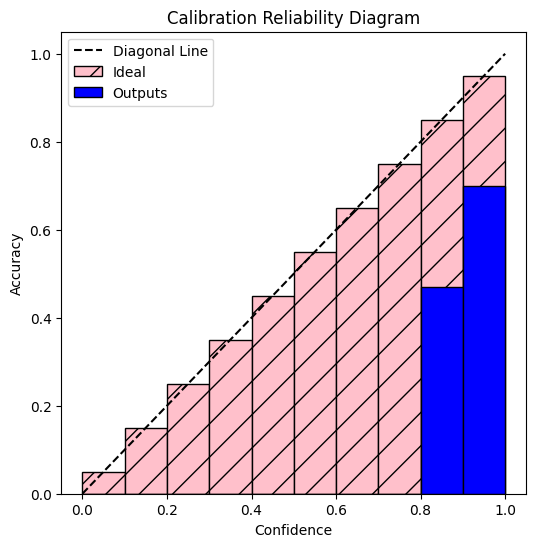


--- Zero-shot Chain-of-Thought ---
ECE: 0.2253903373023214


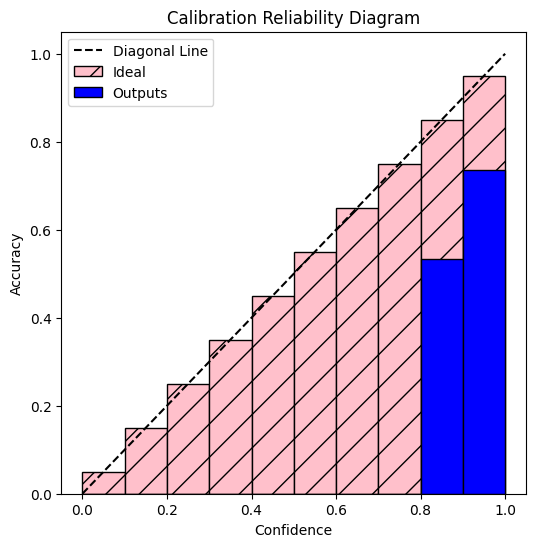


--- 8-shot Answer-only ---
ECE: 0.13009857603633437


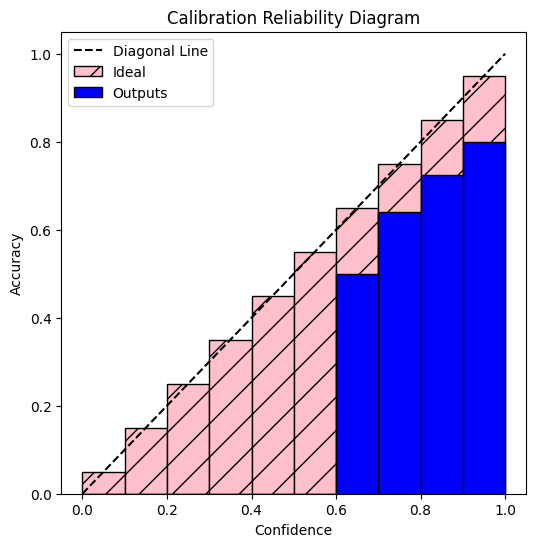


--- 8-shot Chain-of-Thought ---
ECE: 0.13529472951652424


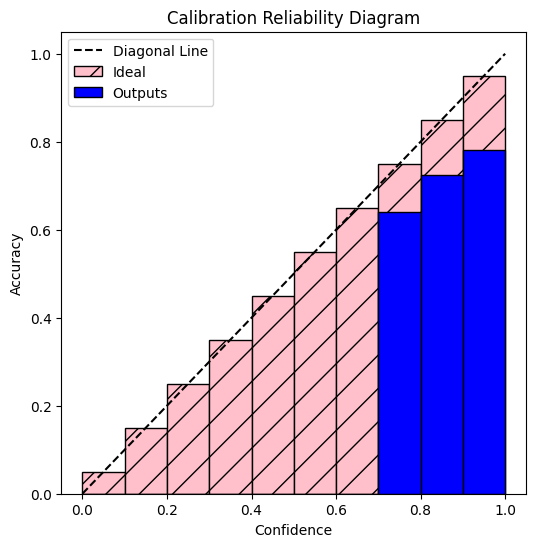

In [24]:
print("--- Zero-shot Answer-only ---")
ece_ao = calculate_ece(acc_list, conf_list)
plot_reliability(acc_list, conf_list)

print("\n--- Zero-shot Chain-of-Thought ---")
ece_cot = calculate_ece(acc_list_cot, conf_list_cot)
plot_reliability(acc_list_cot, conf_list_cot)

print("\n--- 8-shot Answer-only ---")
ece_fs_ao = calculate_ece(acc_list_fewshot, conf_list_fewshot)
plot_reliability(acc_list_fewshot, conf_list_fewshot)

print("\n--- 8-shot Chain-of-Thought ---")
ece_fs_cot = calculate_ece(acc_list_cot_fewshot, conf_list_cot_fewshot)
plot_reliability(acc_list_cot_fewshot, conf_list_cot_fewshot)

Greedy decoding (temperature $T = 0$) is the simplest decoding strategy. Given a prompt, the model always selects the most likely next token at each step, producing a single deterministic output.

However, this approach explores only one reasoning path and may miss alternative solutions. A common alternative is **self-consistency**, which generates multiple outputs by sampling from the model (using $T > 0$) instead of always selecting the most likely token.

# Question 4: Self-Consistency (4 points)

The [self-consistency](https://arxiv.org/abs/2203.11171) approach samples multiple reasoning paths and then selects the final answer based on the most consistent result across these samples.

Instead of relying on a single greedy generation, we generate multiple solutions and choose the answer that appears most frequently.

### Estimating confidence from self-consistency

We can also use these multiple generations to estimate the model's confidence.  
A simple approach is to compute the fraction of generations that agree with the most common answer, and treat this value as a confidence score ([source](https://arxiv.org/abs/2402.13904)).

For example, if 7 out of 10 generated answers agree with the majority answer, the confidence would be 0.7.

This idea can then be used to evaluate calibration in a similar way as before.

Now we will examine how multiple generations and self-consistency affect the calibration of our model.

In [25]:
from collections import Counter

def find_most_voted_with_count(sample_list: list[str]) -> tuple[str, int]:
    """
    Return the most common extracted final answer and its count.

    Args:
        sample_list: List of generation strings.

    Returns:
        (answer, count) with the most-voted answer from sample_list and its count.
    """
    a: list[str] = []
    for s in sample_list:
        a.append(str(extract_final_answer(s)))
    b = max(a, key=a.count)
    return b, a.count(b)

In [ ]:
def calculate_accuracy_and_self_consistency(
    prompt_style,
    **sampling_args,
) -> tuple[list[float], list[float]]:
    """
    Return per-example accuracy and self-consistency confidence.
    For each example, the most frequent extracted answer across samples is used
    as the prediction.

    Args:
        prompt_style: Prompt template string containing `{question}`.
        sampling_args: Overrides for SamplingParams.

    Returns:
        (acc_list, conf_list) as lists of floats.
    """
    # TODO (2 points): Implement self-consistency evaluation.
    # For each question:
    # 1. sample 10 generations (n=10, temperature=0.7 in SamplingParams)
    # 2. take the majority-voted final answer (use find_most_voted_with_count)
    # 3. compute confidence = votes / num_samples
    # 4. compute accuracy against the ground truth
    # Return list of accuracies and confidences per each question.

    acc_list = [0 for test_sample in test_set]
    conf_list = [0 for test_sample in test_set]

    print(f"Final accuracy : {np.mean(acc_list)}")

    return acc_list, conf_list

In [ ]:
# TODO (1 point): Repeat the evaluation from Question 2 using self-consistency decoding.
# For each of the 4 prompts (answer-only/CoT × 0-shot/8-shot):
#  1) compute accuracy and confidence with calculate_accuracy_and_self_consistency(...)
#  2) plot the reliability diagram
#  3) report the ECE

**TODO (1 point):**

1. How does self-consistency affect accuracy compared to greedy decoding? Explain why.
2. How does self-consistency affect model calibration compared to greedy decoding? Explain why.

# Question 5: DPO-style Preference Optimization (7 points)

So far we have evaluated the model using different prompting strategies and studied how these strategies affect both accuracy and calibration. In this section we explore how fine-tuning the model using preference data can change its behavior.

Many modern LLMs are improved using reinforcement learning from human feedback (RLHF). In this approach, models are trained not only on correct answers, but also on preferences between different model outputs (for example, which response is better or more helpful).

A simplified and popular method for preference-based training is [Direct Preference Optimization (DPO)](https://arxiv.org/abs/2305.18290).  
Instead of training a separate reward model (as in PPO-based RLHF), DPO directly trains the language model to increase the probability of preferred responses and decrease the probability of less preferred ones.

In this question, we will:
1. build a preference dataset for DPO,
2. fine-tune the LLM on this dataset,
3. evaluate the fine-tuned model’s accuracy and calibration under different prompting strategies.

In [ ]:
!pip install torchao==0.16.0

## Building a Preference Dataset for DPO

In this section we prepare the training data required for Direct Preference Optimization ([DPO](https://arxiv.org/abs/2305.18290))

Traditional supervised fine-tuning (SFT) trains a model on correct answers. In contrast, DPO trains a model from preferences between two responses. Each training example contains:

- prompt – the input question  
- chosen – the preferred response  
- rejected – the less preferred response  

During training, the model learns to increase the probability of the chosen response relative to the rejected one.

For training we will use the [DPO Trainer from Hugging Face](https://huggingface.co/docs/trl/en/dpo_trainer).

### Where do the preference pairs come from?

Large preference datasets are often created using human feedback (e.g., annotators ranking model outputs).  
However, for some tasks such as math reasoning, we can generate preferences automatically using the known correct answer.

In this assignment we use the training split of the GSM8K dataset. Because GSM8K provides the correct numeric answer, we can automatically determine whether a model's generated solution is correct by comparing the final predicted answer with the ground-truth answer. This allows us to construct preference pairs programmatically.

Conceptually, the process is:

1. Sample several candidate solutions for a GSM8K question from the model.
2. Extract the final numeric answer from each solution.
3. Compare it with the ground-truth answer.
4. Treat a correct solution as the preferred response and an incorrect solution as the less preferred response

These automatically generated pairs form a preference dataset that can be used to train the model with DPO.

In [ ]:
# We will save/load datasets and fine-tuned models using Hugging Face Hub.
#
# What you need to do:
# 1) Create a Hugging Face account (if you don't have one): https://huggingface.co/join
# 2) Create an access token:
#    - Go to your HF profile -> Settings -> Access Tokens
#    - Click "New token"
#    - Important: select a token with WRITE permissions.
#      Make sure to click: "Write access to contents/settings of all repos under your personal namespace"
#      (this is required to push datasets/models and update repo settings).
#    - Save your token somewhere safe.
# 3) Run this cell and paste the token when prompted (your input will be hidden).
#
# Security note: treat the token like a password, do not print it or share it.

from huggingface_hub import login, whoami

login()  # will prompt for your token in the output area

In [ ]:
MY_HF_ID = whoami()["name"]

print(f"Logged in as: {MY_HF_ID}")
print(f"Profile: https://huggingface.co/{MY_HF_ID}")

In [ ]:
import random

def build_dpo_pairs_from_gsm8k(
    ds_train,
    n_pairs: int = 1000,
):
    """
    Build a DPO preference dataset from GSM8K train split using programmatic feedback.

    We sample multiple candidate completions per prompt (single vLLM generate call), auto-label them as
    correct/incorrect based on the extracted final answer, and form (prompt, chosen, rejected) pairs.

    Args:
        ds_train: GSM8K train split (HF Dataset or iterable of dict with 'question' and 'answer').
        n_pairs: Target number of preference pairs to build.

    Returns:
        A list of dicts with keys: 'prompt', 'chosen', 'rejected'.
        May return fewer than n_pairs if not enough prompts yield both correct and incorrect samples.
    """

    ds_shuffled = ds_train.shuffle(seed=42).select(range(n_pairs))

    sampling_params = SamplingParams(
        temperature=0.7,
        max_tokens=500,
        n=10,
    )

    dpo_prompts: list[str] = []
    dpo_correct: list[str] = []
    dpo_incorrect: list[str] = []

    # TODO (2 points): Construct preference pairs from sampled completions.
    # For each question in ds_shuffled:
    #  1) Generate 10 completions with llm.generate(..., sampling_params).
    #  2) Extract the final numeric answer from each completion and compare to the gold answer.
    #  3) If you have at least one correct and one incorrect completion, randomly pick one of each and store:
    #       - dpo_prompts.append(question)
    #       - dpo_correct.append(chosen_correct_text)
    #       - dpo_incorrect.append(chosen_incorrect_text)
    #     Otherwise (all correct or all incorrect), skip that question.

    assert len(dpo_prompts) == len(dpo_correct) == len(dpo_incorrect)

    pairs = []
    for prompt, correct, incorrect in zip(
        dpo_prompts,
        dpo_correct,
        dpo_incorrect,
    ):
        pairs.append({
            "prompt": prompt,
            "chosen": correct,
            "rejected": incorrect,
        })

    return pairs

In [ ]:
from datasets import Dataset, load_dataset

# Build a small preference dataset.
dataset = load_dataset("gsm8k", "main")
train_set = dataset["train"]
test_set = dataset["test"][:200]
dpo_pairs = build_dpo_pairs_from_gsm8k(
    ds_train=train_set,
    n_pairs=1000,
)

print("Number of DPO pairs:", len(dpo_pairs))  # Should produce 600-700 pairs

# Convert to a Hugging Face Dataset and push it to the Hub for reproducibility.
dpo_ds = Dataset.from_list(dpo_pairs)
dpo_ds.push_to_hub(MY_HF_ID + "/gsm8k_dpo_pairs", private=True)
print(f'Saved dataset in https://huggingface.co/datasets/{MY_HF_ID}/gsm8k_dpo_pairs')

## DPO fine-tuning

In this section we fine-tune the base LLM using the preference dataset created earlier and the DPO objective, using the DPO Trainer from Hugging Face. For more information, refer to [documentation](https://huggingface.co/docs/trl/en/dpo_trainer).

### Parameter-efficient fine-tuning with LoRA

Fine-tuning all parameters of an LLM is computationally expensive. Instead, we use the [LoRA (Low-Rank Adaptation)](https://arxiv.org/abs/2106.09685) method for fine-tuning.

LoRA is a fine-tuning technique in which a small set of additional trainable parameters is introduced while the original LLM weights remain frozen. This significantly reduces memory usage and training time while still allowing the model to adapt to new tasks.

Most of the training code is already provided. Your task is to experiment with the DPO hyperparameters to obtain a model that improves performance on GSM8K.

In [ ]:
# Install libraries for DPO training and LoRA
!pip -q install -U trl bitsandbytes

In [ ]:
# We use vLLM only for fast generation (sampling). For training we switch to transformers/trl,
# so we shut down the vLLM engine to free GPU memory.
llm.llm_engine.engine_core.shutdown()

In [ ]:
# Load the base model and tokenizer for DPO training.
# We use LoRA (via peft library) for parameter-efficient fine-tuning.
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import DPOConfig, DPOTrainer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B", use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-Math-1.5B",
    device_map="auto",
    dtype=torch.bfloat16,
)

# Prepare the model for memory-efficient training.
model = prepare_model_for_kbit_training(model)

In [ ]:
from datasets import load_dataset

# Load the preference dataset you created earlier from the Hugging Face Hub.
# It contains (prompt, chosen, rejected) triples for DPO training.
dpo_ds = load_dataset(MY_HF_ID + "/gsm8k_dpo_pairs")["train"]

# Split into train/validation sets so we can monitor training and detect overfitting.
dpo_split = dpo_ds.train_test_split(test_size=0.1, seed=42)
train_dpo = dpo_split["train"]
val_dpo = dpo_split["test"]

print("Train size:", len(train_dpo))
print("Validation size:", len(val_dpo))

# Attach LoRA adapters to the model (parameter-efficient fine-tuning).
# Don't change these LoRA parameters for this assignment.
lora_cfg = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)

# TODO (2 points): Tune DPOConfig hyperparameters below.
# You will receive 2 points if the fine-tuned model evaluated in the next section
# ("Testing the fine-tuned model") achieves higher accuracy than the base model on the GSM8K test set,
# using answer-only zero-shot prompt and the same evaluation code.
#
# Hint 1: try the following hyperparameters:
#  - num_train_epochs
#  - learning_rate
#
# Hint 2: DPO can overfit quickly. It is possible for DPO train/validation loss to decrease
# while test accuracy (see next section, "Testing the fine-tuned model") drops significantly.
# If that happens, try fewer epochs and/or a smaller learning rate.
#
# Note: we guarantee there exists a suitable hyperparameter setting that trains in < 30 minutes,
# but you are free to run longer experiments.

dpo_cfg = DPOConfig(
    output_dir="qwen_dpo_lora_out",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=32,
    learning_rate=1e-4,
    num_train_epochs=1,
    logging_steps=5,
    max_length=500,
    fp16=True,
    eval_strategy="epoch",
    report_to="none",
    per_device_eval_batch_size=1,
)

# Set up and run DPO training.
trainer = DPOTrainer(
    model=model,
    args=dpo_cfg,
    train_dataset=train_dpo,
    eval_dataset=val_dpo,
)
trainer.train()

In [ ]:
# Save the fine-tuned model to Hugging Face Hub for reproducibility.
# This step can take up to 10 minutes.
MODEL_REPO = MY_HF_ID + "/qwen2.5-math-1.5b-dpo-gsm8k"

merged = trainer.model.merge_and_unload()
merged.push_to_hub(MODEL_REPO, private=True)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B", use_fast=True)
tokenizer.push_to_hub(MODEL_REPO, private=True)
print(f"Saved model at: https://huggingface.co/{MODEL_REPO}")

## Testing the fine-tuned model

Now that we have a DPO fine-tuned LLM, we will evaluate its performance.

For evaluation, we recommend **restarting the runtime** to ensure proper vLLM initialization and to clear GPU memory from the training step:

**Runtime → Disconnect and delete runtime → reconnect T4 (upper-right)**

After restarting, continue running the cells below.

In [ ]:
# Install required dependencies

# Note: You may see dependency warnings related to `google-ai-generativelanguage`,
# `tensorflow`, or `grpcio`. These can be safely ignored, as they are not
# required for this assignment.

!pip -q install vllm==0.16.0
!pip -q install protobuf==5.29.6

In [ ]:
from huggingface_hub import login, whoami
login()  # will prompt for your token in the output area

In [ ]:
MY_HF_ID = whoami()["name"]
print(f"Logged in as: {MY_HF_ID}")
print(f"Profile: https://huggingface.co/{MY_HF_ID}")

In [ ]:
# Load the fine-tuned model, can take up to 5-6 mins.
# If you encounter LLM initialization issues, try to restart runtime as recommended above.
from vllm import LLM, SamplingParams

llm = LLM(model=MY_HF_ID + "/qwen2.5-math-1.5b-dpo-gsm8k", gpu_memory_utilization=0.8)

In [ ]:
# TODO (2 points): Evaluate your DPO fine-tuned model using the same evaluation pipeline as in Q2–Q4.
# The only change should be the LLM checkpoint (base model -> fine-tuned model).
# Do not modify prompts, decoding settings, confidence computation, or metrics.
#
# For each of the 4 prompts (answer-only/CoT × 0-shot/8-shot), report:
#  - accuracy
#  - ECE
#  - reliability diagram
#
# Run both settings (for each prompt):
#  - Greedy decoding + logprob-based confidence (calculate_accuracy_and_confidence)
#  - Self-consistency decoding + agreement-based confidence (calculate_accuracy_and_self_consistency)
#
# You can re-run some earlier cells or copy the necessary code here.
#
# Note: You will receive 2 points for DPO fine-tuning (previous section)
# only if answer-only 0-shot accuracy (reported here) is higher than for base model (reported in Q2).

In [ ]:
# TODO (1 point): Explain your results.
# 1) Compare accuracy before vs after DPO across the 4 prompting settings (answer-only/CoT × 0-shot/8-shot):
#    - Which settings improved, which stayed similar, and which got worse?
#    - Give a brief explanation of what might cause these differences.
# 2) Compare calibration (ECE + reliability diagrams) before vs after DPO:
#    - Did calibration improve or degrade?
#    - Explain why you think calibration improved or did not improve.